Notebook to solve basic neoclassical model making use of chebyshev interpolation

In [1]:
# Simple way to call a module - this contains functions for discretizing AR(1)
include("markov_approx.jl")
using LinearAlgebra, QuantEcon, BasisMatrices

# Model with Exogenous Labor Supply

## Defining some functions

### 1. Automate chebyshev interpolation

In [2]:
function cheb_nodes(xlow, xhigh, N)
    basis = Basis(ChebParams(N, xlow, xhigh))
    return nodes(basis)[1], basis 
end

function cheb_interp(x, y, basis)
    Φ = BasisMatrix(basis, Direct(), x, 0) # Direct() does better than Expanded()
    return Φ.vals[1] \ y
end   

cheb_interp (generic function with 1 method)

In [15]:
k, basis = cheb_nodes(2.0, 10.0, 15)
typeof(basis)

Float64

### 2. Main Iteration via endogenous grid point method

In [7]:
function backward_iterate_cheb(cplus, k, basis)
    c_endog = up_inv.( β * Π * ( fk(z, k') .* up.(cplus)))
    c = similar(c_endog)
    for (i, zi) in enumerate(z)
        q = cheb_interp( c_endog[i, :] + k, c_endog[i, :], basis)
        #c[i, :] = funeval(q, basis, f(zi, k)) - avoiding this saves a lot of time
        c[i, :] = BasisMatrix(basis, Direct(), f(zi, k)).vals[1]*q
    end
    return c
end

function ss_policy_cheb(klow, khigh, N; maxit = 10_000, tol = 1E-10)
    k, basis = cheb_nodes(klow, khigh, N)
    c = 0.3 * repeat(k', 3, 1)
    for it in 1:maxit
        cnew = backward_iterate_cheb(c, k, basis)
        if mod(it, 10) ≈ 0 && norm(cnew - c) < tol
            #println("Convergence in $it iterations!")
            return cheb_interp(k, c', basis), basis    
        end
        c = cnew
    end
end

ss_policy_cheb (generic function with 1 method)

### 3. Production and utility functions

In [8]:
f(z, k) = z .* k .^ α .+ (1 - δ) .* k
fk(z, k) =  α .* z .* k .^ (α - 1) .+ (1 - δ) ;
up(c) = 1 / c
up_inv(c) = 1 / c

up_inv (generic function with 1 method)

## Calibration and steady state

In [9]:
z, p, Π = markov_tauchen(0.9, 0.2, N = 3, m = 2);

z *= 0.3;
α = 0.4;
δ = 0.05;
β = 0.95;
z̄ = p ⋅ z;
kstar = ((1 / β - 1 + δ ) / z̄ / α ) ^ (1 / (α - 1));

# grid for capital
k = range(0.5*kstar, 2*kstar, length=300)

0.648839175470723:0.0065100920615791605:2.595356701882892

## Solving the model

In [12]:
q, basis = ss_policy_cheb(k[1], k[end], 10);
typeof(q)

Array{Float64,2}

In [8]:
q, basis = ss_policy_cheb(k[1], k[end], 10);

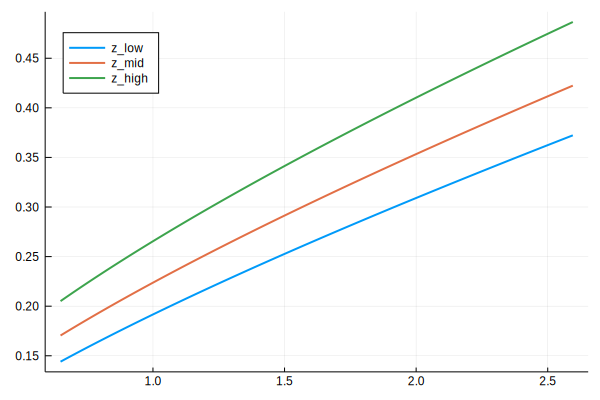

In [9]:
using Plots
c = funeval(q, basis, k)
plot(k, c, label = ["z_low" "z_mid" "z_high"], lw = 2, legend=:topleft)

# Model with Endogenous Labor Supply

We now consider the following version of the model:

$$ V(z, k) = \max_{k',n} u(F(z, k, n) - k') - \nu(n) + \beta E [ V(z', k') \ |  z ] $$

The first order conditions for the problem can be combined into:
$$ v'(n(z, k)) = F_n(z, k, n(z, k)) u'(c(z,k)) $$
$$ u'(c(z, k)) = \beta E [ F_k(z', k'(z, k),n(z',k'(z,k))) u'(c(z',k'(z,k))) | z] $$

### Solving via standard backward iteration

The key idea is that we start with some guess for tomorrow's optimal labor and consumption - call this $n_+$ and $c_+$ - then given this we want to solve for $n(z, k)$ for each $(z, k)$ 

Given a guess for $n(z, k)$ we can get $c(z, k)$ from the first equation and then use the resource contraint to back out $k'(z, k)$ - we then plug this in to the second equation above and see how far off the guess is

## Calibration

In [3]:
z, pi, Π = markov_tauchen(0.9, 0.2, N=3, m=2);
α = 0.4;
δ = 0.05;
β = 0.95;

In [6]:
F(z, k, n) = z .* k.^α .* n.^(1-α) .+ (1 - δ) .* k
Fk(z, k, n) =  α .* z .* (n ./ k).^(1 - α) .+ (1 - δ) 
Fn(z, k, n) = (1 - α) .* z .* (k ./ n).^α

# frisch elasticity of one
vp(n) = n

vp (generic function with 1 method)

### Determinsitc steady state:

In [7]:
k_n = ((1/β - 1 + δ)/α)^(-1/(1-α)) 
D1 = (1-α) * k_n ^ α
D2 = F(1, k_n, 1) - k_n
cstar = sqrt(D1*D2)
nstar = cstar/D2
kstar = k_n*nstar

8.332488818231495

In [8]:
# grid for capital:
klow = 0.4 * kstar
khigh = 2.5 * kstar
k, basis = cheb_nodes(klow, khigh, 15);

Try using the `Tensor()` version from BasisMatrices to do better

In [15]:
function cheb_interp2(y, basis)
    Φ = BasisMatrix(basis, Tensor()) # Direct() does better than Expanded() - try Tensor()
    return Φ.vals[1] \ y
end   

cheb_interp2 (generic function with 1 method)

In [16]:
# Assume nq+ and cq+ are chebyshev representations of n+ and c+
# pr is the vector giving probability of transitioning to each future z, given current z
function FOC(n, z, k, pr, nq₊, cq₊, basis)
    up_c = vp(n) ./ Fn(z, k, n)
    c = up_inv.(up_c)
    k₊ = F(z, k, n) - c
    if k₊ < 0
        return -1E-6
    end
    #c₊ = funeval(cq₊, basis, k₊)
    #n₊ = funeval(nq₊, basis, k₊)
    c₊ = BasisMatrix(basis, Direct(), [k₊] ).vals[1]*cq₊  # make sure to pass [k] not just k - does not work with float
    n₊ = BasisMatrix(basis, Direct(), [k₊] ).vals[1]*nq₊
    inside_E = Fk(z, k₊, n₊) .* up.(c₊)
    return up_c .- β * (pr ⋅ inside_E) 
end

FOC (generic function with 1 method)

We will use the package `Roots` to find the zero of the function via simple bisection algorithm

In [17]:
function backward_iterate(k, nmin, nmax, nq₊, cq₊, basis)
    nq = similar(nq₊) 
    cq = similar(cq₊)
    for (i, z) in enumerate(z)
        #print(i)
        pr = Π[i, :]
        n = similar(k)
        c = similar(k)
        for (j, k) in enumerate(k)
            h(ni) = FOC(ni, z, k, pr, nq₊, cq₊, basis) # need to define aux function 
            n[j] = brent(h, nmin, nmax) #this does a lot better than the f_zero from roots
            c[j] = up_inv(vp(n[j]) / Fn(z, k, n[j]))
        end
        nq[:, i] = cheb_interp2(n, basis)
        cq[:, i] = cheb_interp2(c, basis)
    end
    return nq, cq
end

backward_iterate (generic function with 1 method)

In [20]:
function ss_policy(k, nmin, nmax; maxit = 100, tol = 5E-9, basis = basis)
    c = repeat(cstar/kstar*k', 3, 1)
    n = repeat(nstar*z, 1, length(k))
    cq = cheb_interp2(c', basis)
    nq = cheb_interp2(n', basis)
    for it in 1:maxit
        nq_new, cq_new = backward_iterate(k, nmin, nmax, nq, cq, basis)
        if mod(it, 10) ≈ 0 && norm(nq_new - nq) < tol
            println("Convergence in $it iterations!")
            return nq, cq
        end
        nq = nq_new
        cq = cq_new
    end
end


ss_policy (generic function with 1 method)

In [21]:
using BenchmarkTools
@btime nq, cq = ss_policy(k, 0.2*nstar, 6*nstar)

Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
Convergence in 90 iterations!
  579.430 ms (5622830 allocations: 211.58 MiB)


([0.738506576967582 0.8286083876494528 0.9179408559507455; -0.1188410124026604 -0.11550243636037197 -0.10795223752456867; … ; -1.4654639215484672e-7 -1.0520648307678666e-7 -5.0243764389034716e-8; 4.399367298342327e-8 3.282983919083697e-8 1.986943861251191e-8], [1.8065823194704507 2.092297466112009 2.4681495569102414; 0.9319397807465738 1.0299459622560412 1.1546554363202461; … ; 1.673616020924511e-7 2.604937624006572e-7 3.4465895116551127e-7; -4.557124880126938e-8 -7.695610322462336e-8 -1.2532911493582488e-7])

In [99]:
nq, cq = ss_policy(k, 0.2*nstar, 6*nstar);

Convergence in 80 iterations!


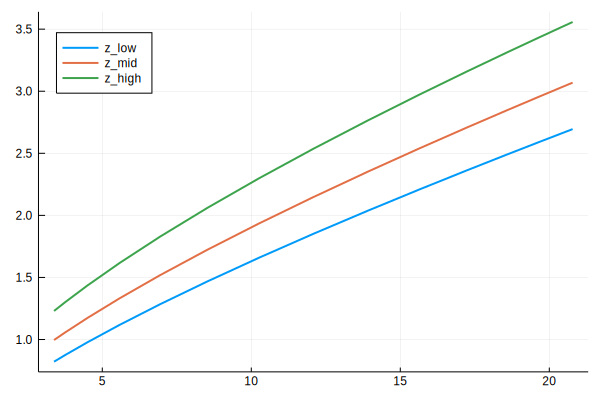

In [100]:
using Plots
c = funeval(cq, basis, k)
n = funeval(nq, basis, k)
plot(k, c, label = ["z_low" "z_mid" "z_high"], lw = 2, legend=:topleft)

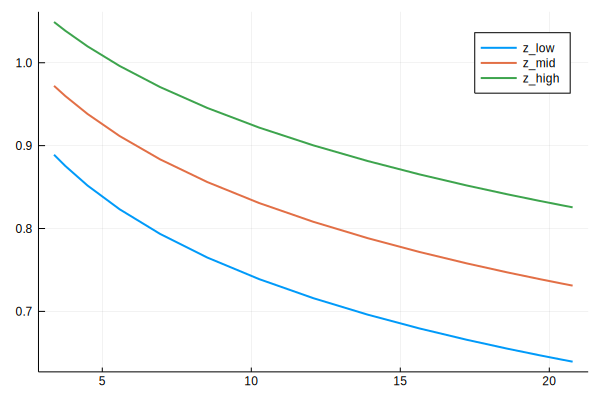

In [102]:
plot(k, n, label = ["z_low" "z_mid" "z_high"], lw = 2, legend=:topright)